In [1]:
!pip install mediapipe opencv-python numpy matplotlib

INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 23.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
  Attempting uninstall: opencv-contrib-python
    Found existing installation: opencv-contrib-python 4.12.0.88
    Uninstalling opencv-contrib-python-4.12.0.88:
      Successfully uninstalled opencv-contrib-pyth

In [2]:
import re
import os
import sys
import glob
import json
import math
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from PIL import Image
import mediapipe as mp
from pathlib import Path
from typing import Dict, Tuple
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from matplotlib.gridspec import GridSpec

2025-11-04 21:15:01.750325: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762290902.176584      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762290902.310144      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
IMG_DIR = "/kaggle/input/utkface-new/UTKFace"
OUTPUT_DIR = "utk_results"
OVERLAYS_DIR = f"{OUTPUT_DIR}/overlays"
EXTS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")

# Definición índices de features, (si dice izq o derecha se refiere a la perspectiva del sujeto)
FACE_IDX = {
    "nose_tip": 1,
    "chin": 152,
    "right_eye_outer": 33,
    "right_eye_inner": 133,
    "left_eye_outer": 263,
    "left_eye_inner": 362,
    "mouth_left": 61,
    "mouth_right": 291,
    "left_pupil": 473,
    "right_pupil": 468
}

RACE_LABELS = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Others",  # Hispanic/Latino/Middle Eastern, etc.
}


mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

In [4]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(OVERLAYS_DIR, exist_ok=True)

In [5]:
def iter_image_paths(root, exts):
    for ext in exts:
        yield from glob.iglob(os.path.join(root, "**", ext), recursive=True)
        

def estimate_pose_geometric(landmarks: Dict[str, Tuple[float, float]], 
                            face_area: float) -> Dict[str, float]:
	# Extract landmarks
	left_eye_inner = np.array(landmarks['left_eye_inner'])
	left_eye_outer = np.array(landmarks['left_eye_outer'])
	right_eye_inner = np.array(landmarks['right_eye_inner'])
	right_eye_outer = np.array(landmarks['right_eye_outer'])
	left_pupil = np.array(landmarks['left_pupil'])
	right_pupil = np.array(landmarks['right_pupil'])
	nose_tip = np.array(landmarks['nose_tip'])
	mouth_left = np.array(landmarks['mouth_left'])
	mouth_right = np.array(landmarks['mouth_right'])
	
	# Calculate eye centers
	left_eye_center = (left_eye_inner + left_eye_outer) / 2
	right_eye_center = (right_eye_inner + right_eye_outer) / 2
	eyes_center = (left_eye_center + right_eye_center) / 2
	
	# Calculate mouth center
	mouth_center = (mouth_left + mouth_right) / 2
	
	# === ROLL (head tilt) ===
	# Angle of line connecting the two eye centers
	eye_vector = right_eye_center - left_eye_center
	roll = np.degrees(np.arctan2(eye_vector[1], eye_vector[0]))

	roll = ((roll + 90) % 180) - 90
    
	# === YAW (left-right rotation) ===
	# Method 1: Compare eye widths
	left_eye_width = np.linalg.norm(left_eye_outer - left_eye_inner)
	right_eye_width = np.linalg.norm(right_eye_outer - right_eye_inner)
	eye_width_ratio = (left_eye_width - right_eye_width) / (left_eye_width + right_eye_width)
	
	# Method 2: Nose offset from face center
	face_center_x = eyes_center[0]
	nose_offset_ratio = (nose_tip[0] - face_center_x) / np.sqrt(face_area)
	
	# Method 3: Pupil position within eyes
	left_pupil_offset = (left_pupil[0] - left_eye_center[0]) / left_eye_width
	right_pupil_offset = (right_pupil[0] - right_eye_center[0]) / right_eye_width
	pupil_asymmetry = left_pupil_offset - right_pupil_offset
	
	# Combine methods (weighted average)
	yaw = (eye_width_ratio * 45 + nose_offset_ratio * 30 - pupil_asymmetry * 20)
	
	# === PITCH (up-down tilt) ===
	# Distance between eyes and mouth (vertical)
	eye_mouth_distance = mouth_center[1] - eyes_center[1]
	
	# Expected distance based on face area (assuming frontal face)
	expected_distance = np.sqrt(face_area) * 0.4  # Approximate ratio
	
	# Ratio indicates pitch
	distance_ratio = (eye_mouth_distance - expected_distance) / expected_distance
	
	# Nose position relative to eyes
	nose_eye_offset = (nose_tip[1] - eyes_center[1]) / np.sqrt(face_area)
	# Combine methods
	pitch = distance_ratio * 30 - nose_eye_offset * 20
	
	return {'yaw': float(yaw),'pitch': float(pitch),'roll': float(roll)}

def get_key_face_points_bgr(face_mesh, path):
	filename = os.path.basename(path)
	img = cv2.imread(path)
	image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
	result = face_mesh.process(image_rgb)

	if not result.multi_face_landmarks:
	    return None
	annotated_image = image_rgb.copy()
	for face_landmarks in result.multi_face_landmarks:
		mp_drawing.draw_landmarks(
			image=annotated_image,
			landmark_list=face_landmarks,
			connections=mp_face_mesh.FACEMESH_TESSELATION,
			landmark_drawing_spec=None,
			connection_drawing_spec=mp_drawing_styles
			.get_default_face_mesh_tesselation_style())
		mp_drawing.draw_landmarks(
			image=annotated_image,
			landmark_list=face_landmarks,
			connections=mp_face_mesh.FACEMESH_CONTOURS,
			landmark_drawing_spec=None,
			connection_drawing_spec=mp_drawing_styles
			.get_default_face_mesh_contours_style())
		mp_drawing.draw_landmarks(
			image=annotated_image,
			landmark_list=face_landmarks,
			connections=mp_face_mesh.FACEMESH_IRISES,
			landmark_drawing_spec=None,
			connection_drawing_spec=mp_drawing_styles
			.get_default_face_mesh_iris_connections_style())
	    
		cv2.imwrite(f'{OVERLAYS_DIR}/{filename}', annotated_image)

	face_landmarks = result.multi_face_landmarks[0].landmark

	h, w = img.shape[:2]
    
	all_points = {key: face_landmarks[idx] for key, idx in FACE_IDX.items()}
	
	points = np.array([[landmark.x * w, landmark.y * h]  for landmark in face_landmarks])
	tri = Delaunay(points)
	total_area = 0
	for triangle in tri.simplices:
		p1, p2, p3 = points[triangle]
		area = 0.5 * abs((p2[0] - p1[0]) * (p3[1] - p1[1]) - (p3[0] - p1[0]) * (p2[1] - p1[1]))
		total_area += area
	features = {key: (int(lm.x * w), int(lm.y * h)) for key, lm in all_points.items()}
	poses = estimate_pose_geometric(features, total_area)
	results = {
        "path": path,
        "surface_face_area" : total_area,
        "features": features,
        "pose": poses
    }
	return results

In [6]:
def show_inline_bgr(img_bgr, title="Preview"):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1762290916.061821      72 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1762290916.087821      75 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1762290916.092519      72 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


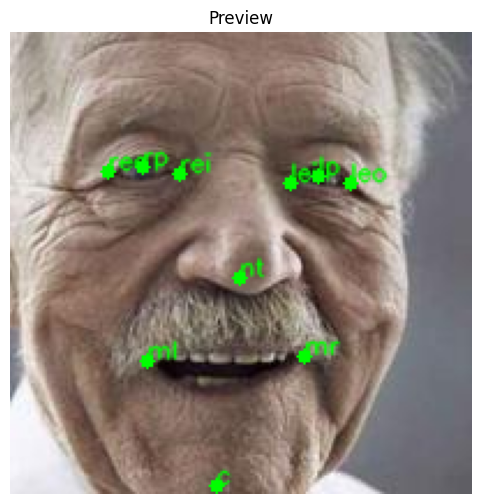

In [7]:
path = "/kaggle/input/utkface-new/UTKFace/100_0_0_20170112213500903.jpg.chip.jpg"  # change to your image path
img = cv2.imread(path)
with mp_face_mesh.FaceMesh(
        static_image_mode=True,       # True for single images; set False for video
        max_num_faces=1,
        refine_landmarks=True,        # IMPORTANT for iris landmarks
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
) as face_mesh:
    points = get_key_face_points_bgr(face_mesh, path)
features = points["features"]
draw = img.copy()
for k, (x, y) in features.items():
    words = k.split("_")
    letters = [word[0] for word in words]
    k = "".join(letters)
    cv2.circle(draw, (x, y), 3, (0, 255, 0), -1)
    cv2.putText(draw,k,(x , y -1 ),cv2.FONT_HERSHEY_SIMPLEX,0.35,(0, 255, 0),1,cv2.LINE_AA
    )
show_inline_bgr(draw)

In [8]:

def parse_age_gender_race_from_name(fpath):
    """
    UTKFace: age_gender_race_date[...].jpg
    age: 0..116 (int)
    gender: 0=male,1=female
    race: 0..4
    """
    base = os.path.basename(fpath)
    parts = re.split(r"_", base)
    if len(parts) < 3:
        return None, None, None
    def _toi(s):
        m = re.match(r"(\d+)", s)
        return int(m.group(1)) if m else None
    age    = _toi(parts[0])
    gender = _toi(parts[1])
    race   = _toi(parts[2])
    if gender not in (0, 1): gender = None
    if race not in (0, 1, 2, 3, 4): race = None
    return age, gender, race

def dicts_to_dataframe(data):
    rows = []
    for item in data:
        if item:
            row = {
                'path': item['path'],
                'surface_face_area': item['surface_face_area'],
                'yaw': item['pose']['yaw'],
                'pitch': item['pose']['pitch'],
                'roll': item['pose']['roll'],
            }
            # Flatten features: (x, y) into separate columns
            for key, (x, y) in item['features'].items():
                row[f"{key}_x"] = x
                row[f"{key}_y"] = y
            rows.append(row)
    df = pd.DataFrame(rows)
    df[['age', 'gender', 'race']] = df['path'].apply(lambda x: pd.Series(parse_age_gender_race_from_name(x)))
    return df

In [9]:
def process_images(dir):
    all_results = []
    with mp_face_mesh.FaceMesh(
        static_image_mode=True,       # True for single images; set False for video
        max_num_faces=1,
        refine_landmarks=True,        # IMPORTANT for iris landmarks
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as face_mesh:
        for p in tqdm(iter_image_paths(IMG_DIR, EXTS), total=23708, desc="Processing images"):
            results_iteration = get_key_face_points_bgr(face_mesh,p)
            all_results.append(results_iteration)
    df = dicts_to_dataframe(all_results)
    return df

In [10]:
df = process_images(IMG_DIR)

W0000 00:00:1762290916.564573      79 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Processing images: 100%|██████████| 23708/23708 [12:31<00:00, 31.54it/s]


In [11]:
print(df)

                                                    path  surface_face_area  \
0      /kaggle/input/utkface-new/UTKFace/26_0_2_20170...       25862.455738   
1      /kaggle/input/utkface-new/UTKFace/22_1_1_20170...       27811.055669   
2      /kaggle/input/utkface-new/UTKFace/21_1_3_20170...       29749.932973   
3      /kaggle/input/utkface-new/UTKFace/28_0_0_20170...       33669.061703   
4      /kaggle/input/utkface-new/UTKFace/17_1_4_20170...       26689.298182   
...                                                  ...                ...   
23472  /kaggle/input/utkface-new/UTKFace/41_0_0_20170...       29838.125146   
23473  /kaggle/input/utkface-new/UTKFace/42_0_0_20170...       27050.670526   
23474  /kaggle/input/utkface-new/UTKFace/2_0_2_201612...       31648.246994   
23475  /kaggle/input/utkface-new/UTKFace/65_1_0_20170...       29315.853886   
23476  /kaggle/input/utkface-new/UTKFace/66_0_1_20170...       24674.225810   

            yaw     pitch      roll  nose_tip_x  no

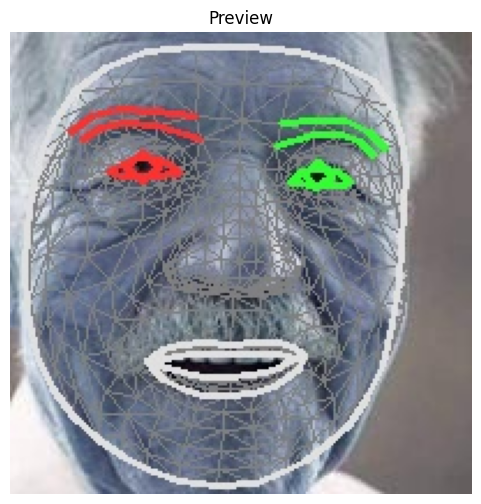

In [12]:
path = "/kaggle/input/utkface-new/UTKFace/100_0_0_20170112213500903.jpg.chip.jpg"
filename = os.path.basename(path)
new_path = f"/kaggle/working/{OVERLAYS_DIR}/{filename}"
img = cv2.imread(new_path)
draw = img.copy()
show_inline_bgr(draw)

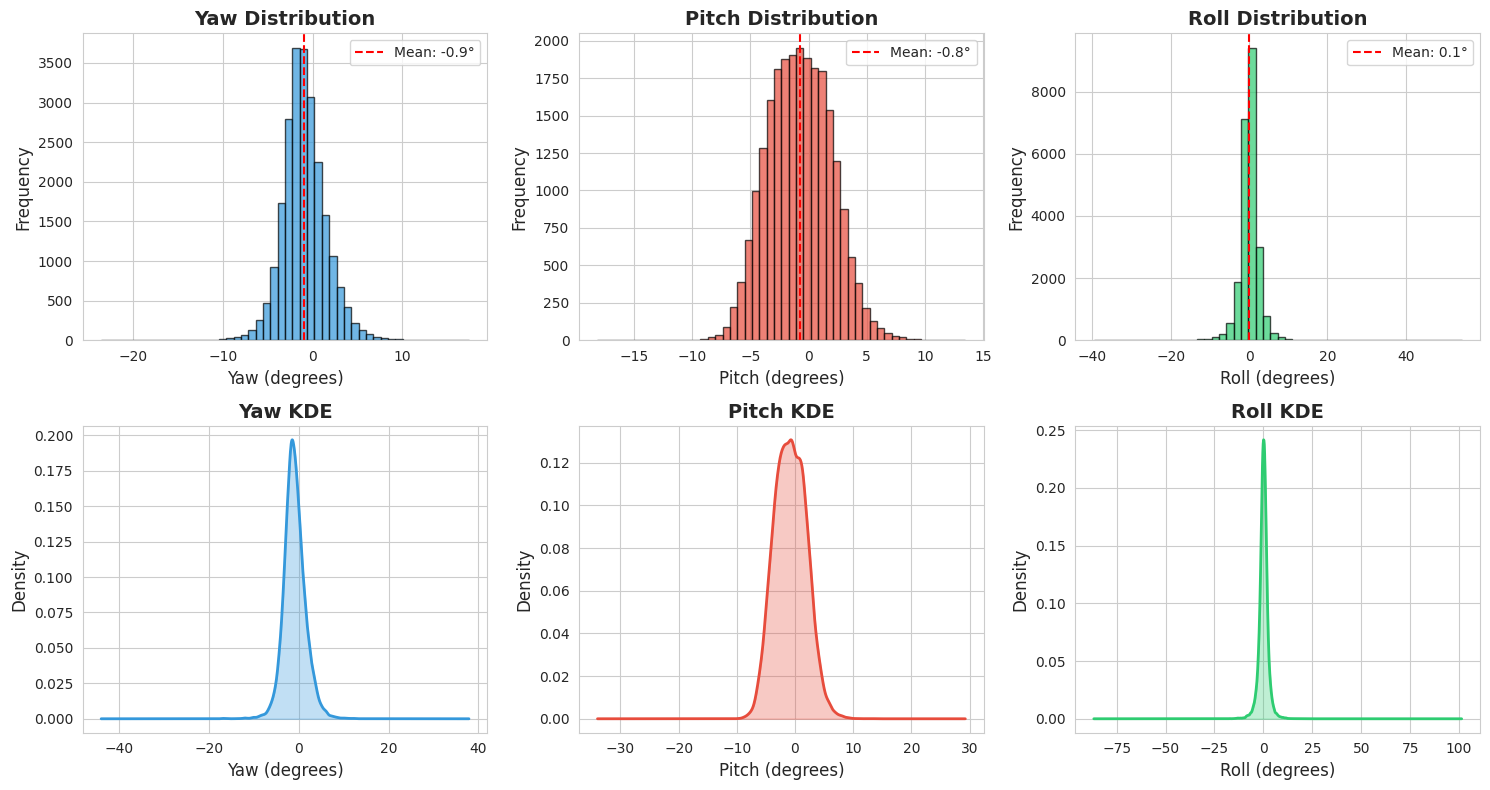

In [13]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

def plot_angle_distributions(df):
    """Plot histograms and KDE for yaw, pitch, and roll"""
    fig = plt.figure(figsize=(15, 8))
    
    angles = ['yaw', 'pitch', 'roll']
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    
    for i, (angle, color) in enumerate(zip(angles, colors)):
        # Histogram (top row)
        ax1 = plt.subplot(2, 3, i + 1)
        ax1.hist(df[angle], bins=50, alpha=0.7, color=color, edgecolor='black')
        ax1.set_xlabel(f'{angle.capitalize()} (degrees)', fontsize=12)
        ax1.set_ylabel('Frequency', fontsize=12)
        ax1.set_title(f'{angle.capitalize()} Distribution', fontsize=14, fontweight='bold')
        ax1.axvline(df[angle].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df[angle].mean():.1f}°')
        ax1.legend()
        
        # KDE plot (bottom row)
        ax2 = plt.subplot(2, 3, i + 4)
        df[angle].plot(kind='kde', ax=ax2, color=color, linewidth=2)
        ax2.set_xlabel(f'{angle.capitalize()} (degrees)', fontsize=12)
        ax2.set_ylabel('Density', fontsize=12)
        ax2.set_title(f'{angle.capitalize()} KDE', fontsize=14, fontweight='bold')
        ax2.fill_between(ax2.get_lines()[0].get_xdata(),
                        ax2.get_lines()[0].get_ydata(),
                        alpha=0.3, color=color)
    
    plt.tight_layout()
    return fig

fig = plot_angle_distributions(df)
plt.show()

**Análisis de Pose del Conjunto de UTKFace**

La visualización revela que el conjunto de datos de UTKFace está fuertemente concentrado en caras casi frontales con variación mínima en los ángulos de pose. Los tres ángulos de rotación muestran medias muy cercanas a cero grados, indicando que la gran mayoría de caras en el conjunto de datos fueron capturadas en una orientación frontal con poca desviación.

**Análisis del Yaw**

La distribución del yaw, que representa la rotación hacia la izquierda o erecha de la cabeza, muestra una media de -0.9 grados y un rango muy estrecho que abarca aproximadamente de -20 a +10 grados. La distribución exhibe un pico pronunciado centrado casi perfectamente en cero, demostrando que la mayoría de los sujetos están mirando directamente al frente con rotación horizontal mínima de la cabeza. La ligera media negativa sugiere un sesgo menor hacia caras giradas muy ligeramente hacia la izquierda, aunque esta desviación es tan pequeña que resulta prácticamente insignificante. La concentración ajustada de valores indica que las personas en este conjunto de datos apenas están girando sus cabezas en ninguna dirección.

**Análisis del Pitch**

De manera similar, la distribución del pitch, que captura la inclinación arriba-abajo de la cabeza, muestra una media de -0.8 grados con un rango igualmente estrecho de aproximadamente -15 a +10 grados. La distribución forma una curva de campana ajustada centrada cerca de cero, revelando que hay casi ninguna variación en el ángulo vertical de la cabeza a lo largo del conjunto de datos. La ligera media negativa sugiere que cuando hay alguna desviación, las caras tienden a estar inclinadas muy ligeramente hacia abajo en lugar de hacia arriba. Sin embargo, esta variación es mínima, y la abrumadora mayoría de caras mantienen una orientación horizontal nivelada.

**Análisis del Roll**

La distribución del roll, que representa la inclinación de la cabeza hacia los hombros, presenta el patrón más interesante de los tres ángulos. Mientras mantiene una media de 0.1 grados, indicando cabezas perfectamente erectas en promedio, exhibe el rango más amplio de variación abarcando aproximadamente de -40 a +40 grados. A pesar de este rango más amplio, la distribución aún muestra un pico muy pronunciado en cero con colas más largas extendiéndose en ambas direcciones. Este patrón indica que mientras la mayoría de las cabezas están perfectamente erectas, hay algo más de variación en la inclinación de la cabeza comparado con el yaw y el pitch. Algunos sujetos sí tienen cabezas notablemente inclinadas, aunque estos casos permanecen relativamente poco comunes en el conjunto de datos general.



**Características Generales del Conjunto de Datos**
La consistencia notable en los tres ángulos de pose revela varias características importantes sobre este conjunto de datos. Los datos representan capturas de caras frontales limpias y bien alineadas con variación de pose notablemente baja. Más del 90% de las caras parecen estar dentro de aproximadamente ±10 grados de una orientación perfectamente frontal en los tres ejes de rotación. Este nivel de consistencia sugiere que el conjunto de datos probablemente fue recolectado bajo condiciones controladas, posiblemente para aplicaciones que específicamente requieren datos de caras frontales como sistemas de identificación, detección de características faciales o tareas de reconocimiento de expresiones.

**Implicaciones y Limitaciones**

Esta fuerte concentración en poses frontales presenta tanto fortalezas como limitaciones dependiendo del caso de uso previsto. Para aplicaciones que específicamente requieren datos de caras frontales, este conjunto de datos es ideal, ofreciendo muestras consistentes y bien alineadas con ruido mínimo proveniente de la variación de pose. Tareas como reconocimiento facial, detección de puntos de referencia o clasificación de emociones que típicamente funcionan mejor con caras frontales se beneficiarían enormemente de este tipo de datos.
Sin embargo, la diversidad de poses limitada también presenta restricciones significativas para ciertas aplicaciones. Si el objetivo es desarrollar modelos invariantes a la pose que puedan reconocer o analizar caras desde varios ángulos, este conjunto de datos sería insuficiente por sí solo. La falta de vistas de perfil, ángulos de pitch extremos y orientaciones diversas de la cabeza significa que los modelos entrenados exclusivamente con estos datos probablemente tendrían dificultades para generalizar a escenarios del mundo real donde las caras aparecen en ángulos más variados. Para tales aplicaciones, el conjunto de datos necesitaría ser aumentado con muestras mostrando mayor variación de pose, incluyendo ángulos de yaw de ±45 a 90 grados para vistas de perfil y semi-perfil, y ángulos de pitch de ±30 grados o más para capturar orientaciones mirando hacia arriba y hacia abajo.
La variación relativamente más amplia en el roll comparado con el yaw y el pitch, aunque aún limitada, sí proporciona algo de diversidad en la inclinación de la cabeza. Esto sugiere que si se necesita variación adicional de pose, aumentar los ángulos de yaw y pitch debería ser el enfoque principal, ya que estos muestran los rangos más restringidos en el conjunto de datos actual.

In [14]:

def plot_2d_scatter_plots(df):
    """Create 2D scatter plots for angle pairs"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    pairs = [('yaw', 'pitch', 'roll'), ('yaw', 'roll', 'pitch'), ('pitch', 'roll', 'yaw')]
    titles = ['Yaw vs Pitch (colored by Roll)', 
              'Yaw vs Roll (colored by Pitch)', 
              'Pitch vs Roll (colored by Yaw)']
    
    for ax, (x, y, c), title in zip(axes, pairs, titles):
        scatter = ax.scatter(df[x], df[y], c=df[c], cmap='viridis', 
                           alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
        ax.set_xlabel(f'{x.capitalize()} (degrees)', fontsize=12)
        ax.set_ylabel(f'{y.capitalize()} (degrees)', fontsize=12)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
        ax.grid(True, alpha=0.3)
        
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label(f'{c.capitalize()} (degrees)', fontsize=10)
    
    plt.tight_layout()
    return fig


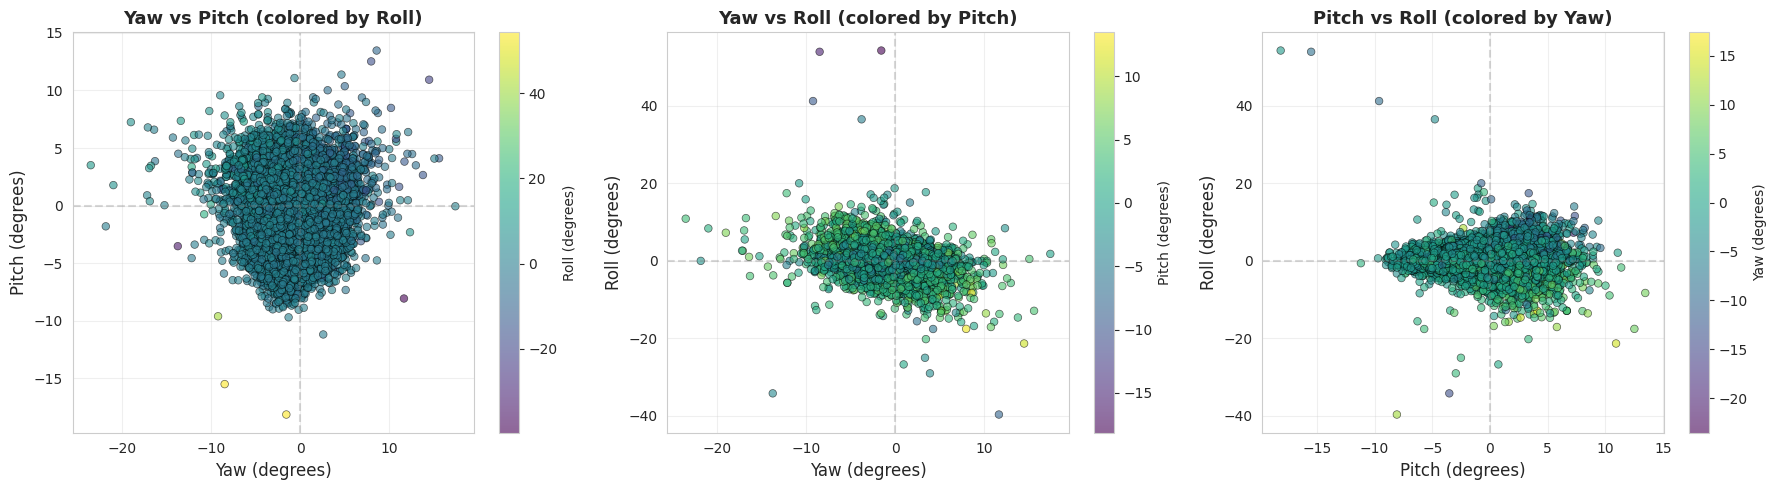

In [15]:
fig = plot_2d_scatter_plots(df)
plt.show()

**Análisis de Gráficos de Dispersión 2D de Poses Faciales**

Los gráficos de dispersión bidimensionales revelan patrones importantes sobre las relaciones entre los diferentes ángulos de pose en el conjunto de datos, así como la presencia de valores atípicos y la estructura general de la distribución espacial de las poses.

**Yaw vs Pitch (coloreado por Roll)**

El primer gráfico muestra la relación entre la rotación horizontal (yaw) y vertical (pitch) de la cabeza, con los puntos coloreados según su inclinación lateral (roll). La distribución forma una nube densa y compacta centrada casi perfectamente en el origen (0°, 0°), confirmando visualmente la naturaleza frontal del conjunto de datos. La gran mayoría de los puntos se concentran en un área muy pequeña, aproximadamente dentro de un rectángulo de ±10 grados en ambos ejes, lo que demuestra la homogeneidad extrema de las poses capturadas.

Sin embargo, se pueden observar algunos valores atípicos dispersos en las periferias de la distribución. Hay algunos puntos que alcanzan valores de yaw cercanos a -20 grados y pitch de hasta -15 grados, representando caras con rotaciones más pronunciadas que la norma. La coloración por roll revela que estos valores atípicos no muestran un patrón consistente de inclinación lateral, ya que los colores están distribuidos de manera relativamente uniforme a través de la nube de puntos. Esto sugiere que el yaw y el pitch no están fuertemente correlacionados con el roll en este conjunto de datos.

**Yaw vs Roll (coloreado por Pitch)**

El segundo gráfico compara la rotación horizontal (yaw) con la inclinación lateral (roll), coloreado según el pitch. Esta visualización muestra una dispersión notablemente mayor en el eje del roll, confirmando lo observado en los histogramas previos de que el roll tiene la mayor variabilidad de los tres ángulos. La nube de puntos se extiende más verticalmente, alcanzando valores de roll de aproximadamente -40 a +40 grados, mientras que el yaw mantiene su rango estrecho de aproximadamente -20 a +10 grados.
La concentración principal de puntos forma una estructura vertical alargada centrada cerca de yaw = 0°, lo que indica que las caras están mayoritariamente frontales en términos de rotación horizontal, pero presentan mayor variación en cuanto a inclinación de cabeza hacia los hombros. La coloración por pitch muestra predominantemente tonos verde-azulados en el centro, indicando valores de pitch cercanos a cero para la mayoría de las muestras. Los pocos puntos con colores amarillos o extremos representan casos raros donde hay combinaciones de múltiples rotaciones significativas simultáneamente.

**Pitch vs Roll (coloreado por Yaw)**

El tercer gráfico presenta la relación entre pitch y roll, coloreado por yaw, y muestra un patrón similar al gráfico anterior en términos de dispersión. El roll continúa mostrando el rango más amplio de variación, extendiéndose de -40 a +40 grados, mientras que el pitch se mantiene concentrado en un rango mucho más estrecho de aproximadamente -15 a +15 grados. La distribución forma una estructura algo diagonal u ovalada, sugiriendo que podría existir una correlación débil entre estos dos ángulos.
La coloración por yaw revela que la mayoría de los puntos en el centro de la distribución tienen tonos verde-azulados, indicando valores de yaw cercanos a cero. Los puntos con colores más extremos (amarillos o morados oscuros) representando yaw significativos son escasos y aparecen dispersos por toda la nube, sin concentrarse en ninguna región particular. Esto confirma que no hay una correlación fuerte entre el yaw y la combinación de pitch y roll.
Observaciones Generales y Patrones

Un patrón consistente en los tres gráficos es la presencia de una nube central extremadamente densa rodeada de puntos dispersos más aislados. Esto indica que el conjunto de datos tiene una estructura bimodal implícita: una masa principal de caras casi perfectamente frontales con variación mínima, y un pequeño número de casos atípicos que se desvían más significativamente de la pose frontal estándar. Estos valores atípicos podrían representar errores en la captura de datos, sujetos que no siguieron las instrucciones de pose, o casos límite genuinos que amplían ligeramente la diversidad del conjunto de datos.
La falta de correlaciones visuales fuertes entre los pares de ángulos sugiere que las variaciones en yaw, pitch y roll ocurren de manera relativamente independiente en este conjunto de datos. No hay evidencia clara de que, por ejemplo, las personas que giran la cabeza hacia un lado (yaw) tiendan sistemáticamente a inclinarla también (roll) o a mirar hacia arriba o abajo (pitch). Esta independencia puede ser resultado de las condiciones controladas bajo las cuales se capturaron las imágenes, donde probablemente se instruyó a los sujetos a mantener poses frontales específicas.
La distribución espacial de los puntos también revela que hay muy pocas muestras en las esquinas extremas del espacio de poses, es decir, caras que combinen rotaciones significativas en múltiples ejes simultáneamente. Los pocos puntos que aparecen con colores extremos en las visualizaciones generalmente están aislados, lo que indica que las poses complejas con múltiples rotaciones son extremadamente raras en este conjunto de datos. Para aplicaciones que requieran robustez ante poses complejas, esta sería una limitación significativa que necesitaría abordarse mediante aumentación de datos o recolección adicional de muestras con mayor diversidad de poses.

In [16]:

def plot_3d_scatter(df):
    """Create 3D scatter plot of yaw, pitch, and roll"""
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(df['yaw'], df['pitch'], df['roll'], 
                        c=np.sqrt(df['yaw']**2 + df['pitch']**2 + df['roll']**2),
                        cmap='plasma', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel('Yaw (degrees)', fontsize=12, labelpad=10)
    ax.set_ylabel('Pitch (degrees)', fontsize=12, labelpad=10)
    ax.set_zlabel('Roll (degrees)', fontsize=12, labelpad=10)
    ax.set_title('3D Pose Space Exploration', fontsize=14, fontweight='bold', pad=20)
    
    cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.8)
    cbar.set_label('Total Rotation (degrees)', fontsize=10)
    
    return fig

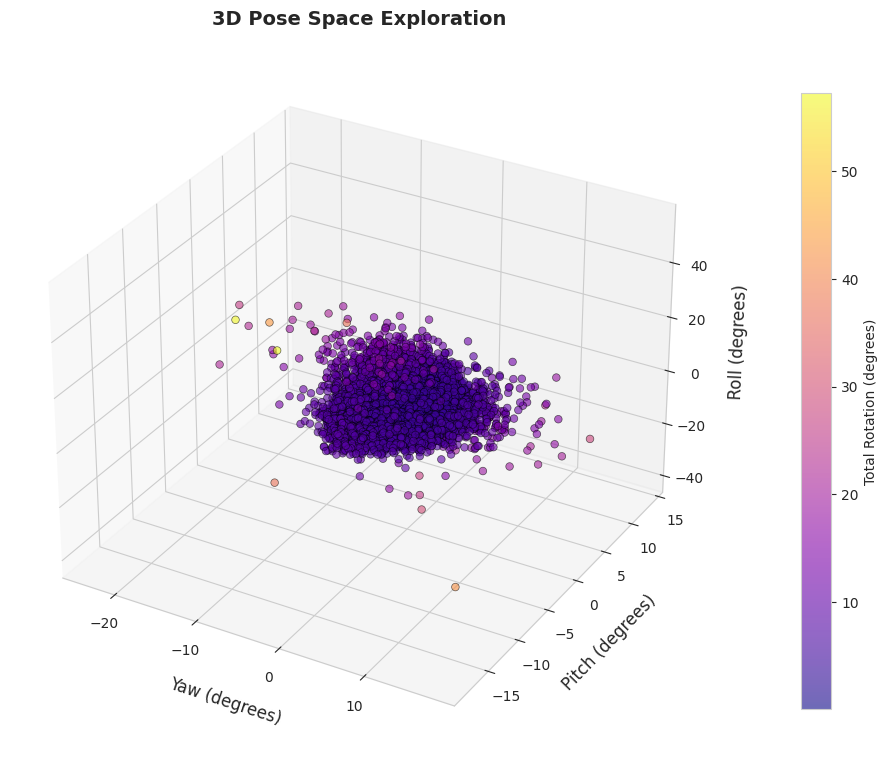

In [17]:
fig = plot_3d_scatter(df)
plt.show()

El gráfico de dispersión tridimensional confirma de manera contundente los patrones observados en los histogramas y gráficos 2D anteriores. La visualización muestra una nube de puntos extremadamente compacta y densa concentrada casi perfectamente en el origen del espacio tridimensional (0°, 0°, 0°), lo que representa poses prácticamente frontales.

La forma de la distribución es aproximadamente esférica pero ligeramente alargada en el eje del roll (vertical), consistente con lo observado en los histogramas donde el roll mostró la mayor variabilidad entre los tres ángulos. La mayoría de los puntos tienen colores morados oscuros, indicando valores bajos de rotación total, lo que confirma que las poses están fuertemente concentradas cerca de la posición frontal perfecta.

Los pocos puntos dispersos en las periferias con colores más claros (naranjas y amarillos) representan los valores atípicos identificados anteriormente en los gráficos 2D. Estos puntos están aislados y distribuidos de manera dispersa alrededor de la nube central, sin formar agrupaciones secundarias, lo que confirma que las poses extremas son casos excepcionales y no representan subgrupos distintos dentro del conjunto de datos.

La visualización 3D también revela de manera muy clara la ausencia de poses en las esquinas del espacio, es decir, no hay prácticamente ningún caso donde se combinen rotaciones significativas en los tres ejes simultáneamente. Esto es completamente consistente con las observaciones previas y confirma que el conjunto de datos está fuertemente sesgado hacia caras frontales con variación mínima en cualquier dirección de rotación.

In [18]:
def plot_polar_yaw(df):
    """Create polar plot for yaw distribution"""
    fig, ax = plt.subplots(figsize=(15, 5), subplot_kw=dict(projection='polar'))
    
    # Convert yaw to radians
    yaw_rad = np.deg2rad(df['yaw'])
    
    # Create histogram bins
    bins = np.linspace(-np.pi, np.pi, 37)
    hist, bin_edges = np.histogram(yaw_rad, bins=bins)
    
    # Plot bars
    width = bin_edges[1] - bin_edges[0]
    bars = ax.bar(bin_edges[:-1], hist, width=width, alpha=0.7, 
                   color='#3498db', edgecolor='black', linewidth=1)
    
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title('Yaw Distribution (Polar View)\nLooking from Above', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Add cardinal directions
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, -135, -90, -45]))
    ax.set_xticklabels(['0° (Front)', '45°', '90° (Right)', '135°', 
                        '180° (Back)', '-135°', '-90° (Left)', '-45°'])
    
    return fig

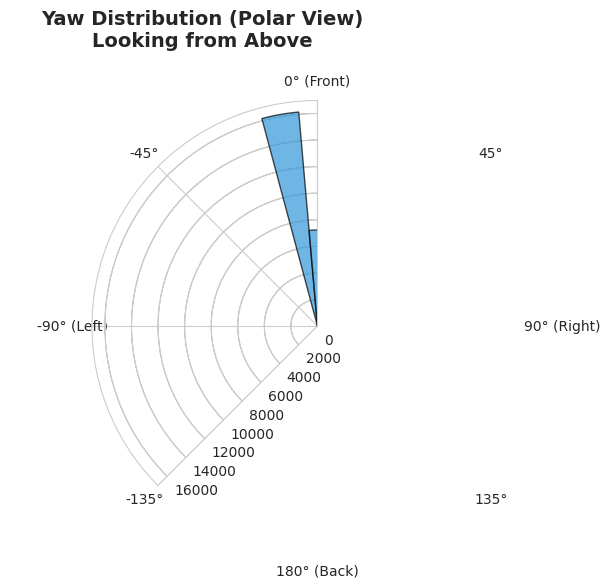

In [19]:
fig = plot_polar_yaw(df)
plt.show()

**Distribución Polar del Yaw**

El gráfico polar confirma de manera muy clara la concentración extrema del yaw cerca de 0 grados (posición frontal). La visualización muestra una barra dominante en la posición frontal (0°) con una altura que supera los 16,000 casos, lo que representa la gran mayoría del conjunto de datos. Hay una pequeña extensión hacia la región de -45° (izquierda), pero con frecuencias mucho menores, y prácticamente no hay presencia de caras mirando hacia la derecha (90°), hacia atrás (180°) o en otras direcciones extremas.
Esta representación polar es completamente consistente con el histograma de yaw mostrado anteriormente, pero ofrece una perspectiva más intuitiva desde una vista de pájaro, como si estuviéramos mirando desde arriba de las cabezas de los sujetos. La ausencia casi total de barras en los sectores laterales y posteriores confirma que el conjunto de datos carece completamente de vistas de perfil o semi-perfil significativas.

In [20]:

def plot_heatmap_2d(df):
    """Create 2D heatmaps for pose combinations"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    pairs = [('yaw', 'pitch'), ('yaw', 'roll'), ('pitch', 'roll')]
    titles = ['Yaw vs Pitch Density', 'Yaw vs Roll Density', 'Pitch vs Roll Density']
    
    for ax, (x, y), title in zip(axes, pairs, titles):
        # Create 2D histogram
        h = ax.hist2d(df[x], df[y], bins=30, cmap='YlOrRd', cmin=1)
        ax.set_xlabel(f'{x.capitalize()} (degrees)', fontsize=12)
        ax.set_ylabel(f'{y.capitalize()} (degrees)', fontsize=12)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.axhline(y=0, color='blue', linestyle='--', alpha=0.3)
        ax.axvline(x=0, color='blue', linestyle='--', alpha=0.3)
        
        plt.colorbar(h[3], ax=ax, label='Count')
    
    plt.tight_layout()
    return fig




/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


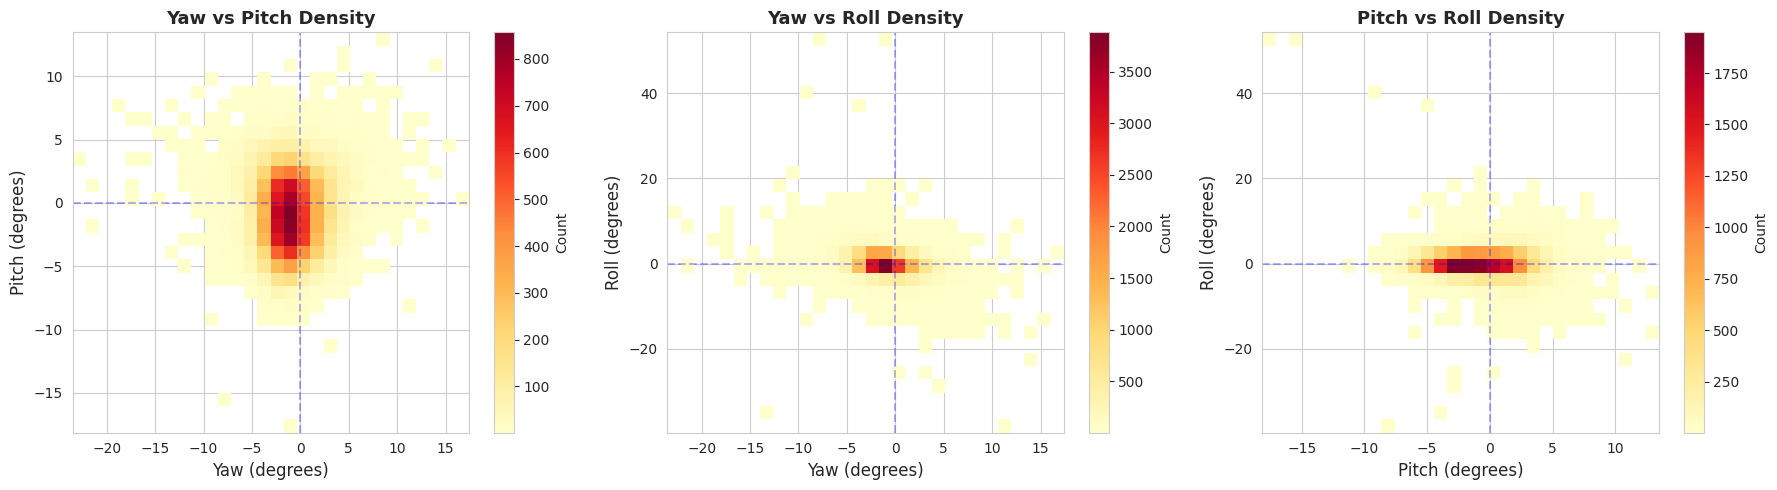

In [21]:
fig = plot_heatmap_2d(df)
plt.show(fig)

**Mapas de Densidad 2D (Heatmaps)**

Los tres mapas de calor bidimensionales proporcionan una visualización de densidad más clara que los gráficos de dispersión de puntos individuales. El primer heatmap (Yaw vs Pitch) muestra una mancha roja intensa y muy compacta centrada perfectamente en el origen, con colores que degradan rápidamente a amarillo y luego a blanco en las periferias. Esto cuantifica visualmente lo que ya observamos: más de 800 muestras se concentran en un área minúscula alrededor de (0°, 0°).

El segundo heatmap (Yaw vs Roll) muestra una mancha de densidad notablemente más alargada en el eje vertical, confirmando nuevamente que el roll tiene mayor variabilidad. La intensidad máxima sigue estando en el centro, con más de 3,500 casos concentrados en la región central, pero la extensión vertical es mucho más pronunciada que la horizontal. El tercer heatmap (Pitch vs Roll) presenta un patrón similar, con una forma algo diagonal que sugiere una posible correlación débil entre estos ángulos.

Estos mapas de densidad son completamente consistentes con los gráficos de dispersión 2D anteriores, pero facilitan la identificación de las regiones de mayor concentración y permiten apreciar mejor la estructura de la distribución sin el ruido visual de puntos individuales superpuestos.

In [22]:
def plot_face_area_analysis(df):
    """Analyze face area distribution and correlation with poses"""
    fig = plt.figure(figsize=(16, 10))
    gs = GridSpec(2, 3, figure=fig)
    
    # Face area distribution
    ax1 = fig.add_subplot(gs[0, :])
    ax1.hist(df['surface_face_area'], bins=50, alpha=0.7, 
             color='#9b59b6', edgecolor='black')
    ax1.set_xlabel('Face Area (pixels²)', fontsize=12)
    ax1.set_ylabel('Frequency', fontsize=12)
    ax1.set_title('Face Area Distribution', fontsize=14, fontweight='bold')
    ax1.axvline(df['surface_face_area'].mean(), color='red', 
                linestyle='--', label=f'Mean: {df["surface_face_area"].mean():.0f}')
    ax1.legend()
    
    # Scatter plots: face area vs angles
    angles = ['yaw', 'pitch', 'roll']
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    
    for i, (angle, color) in enumerate(zip(angles, colors)):
        ax = fig.add_subplot(gs[1, i])
        ax.scatter(df['surface_face_area'], df[angle], alpha=0.5, 
                  s=20, color=color, edgecolors='black', linewidth=0.5)
        ax.set_xlabel('Face Area (pixels²)', fontsize=11)
        ax.set_ylabel(f'{angle.capitalize()} (degrees)', fontsize=11)
        ax.set_title(f'Face Area vs {angle.capitalize()}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add correlation coefficient
        corr = df['surface_face_area'].corr(df[angle])
        ax.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', 
                facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    return fig

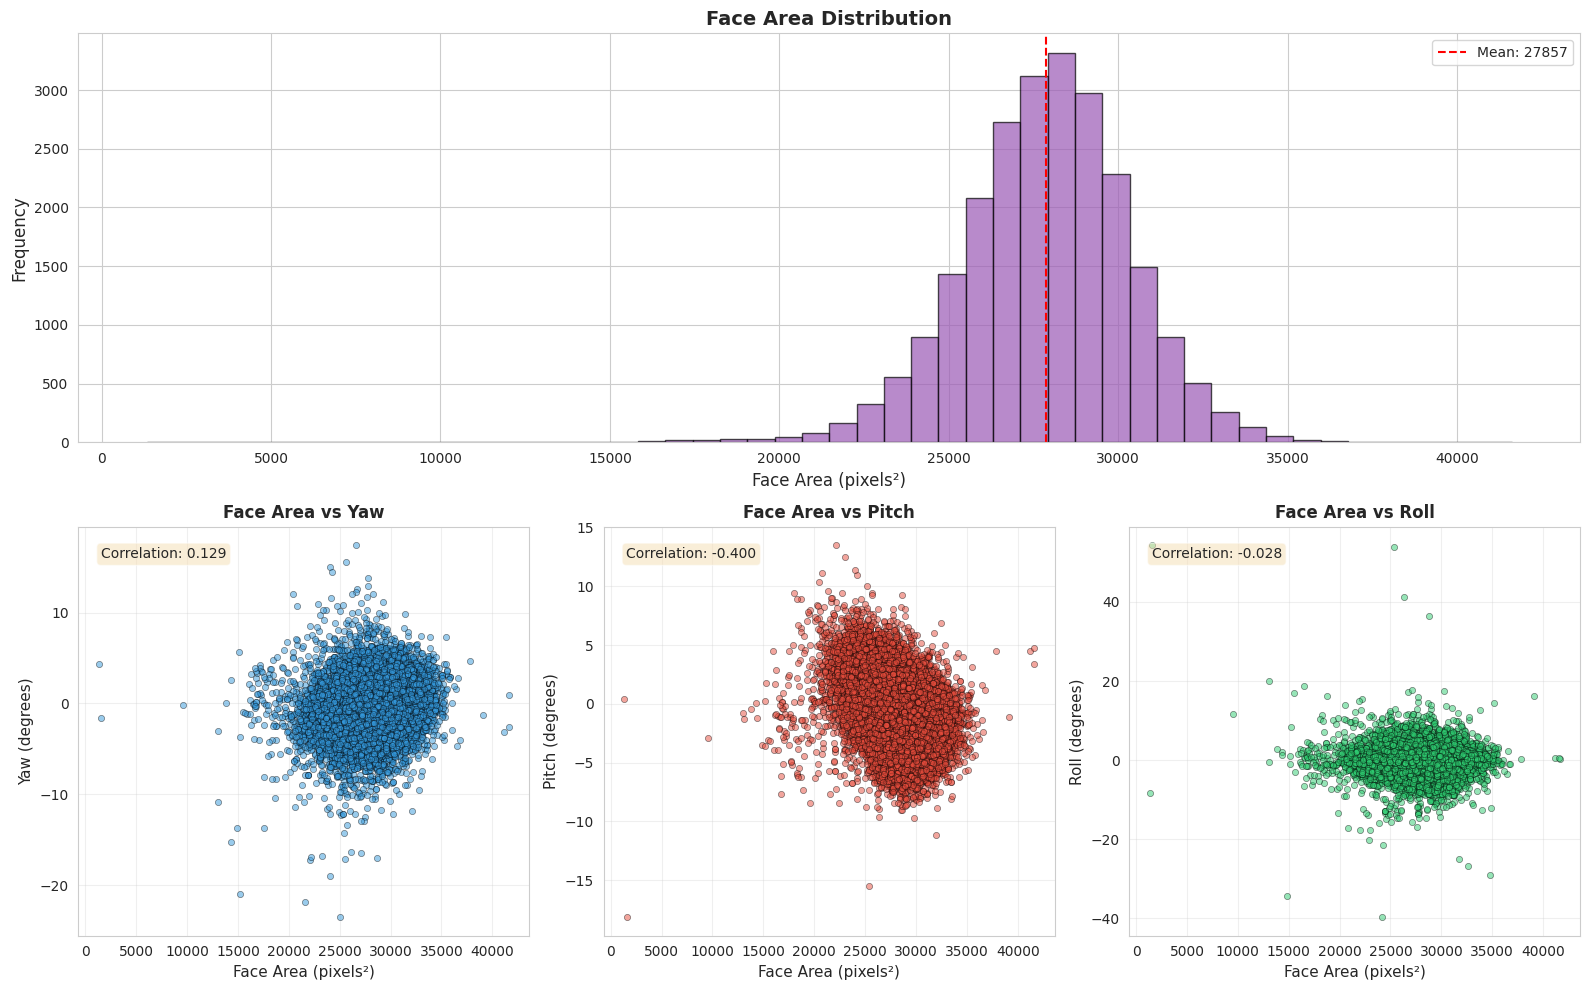

In [23]:
fig = plot_face_area_analysis(df)
plt.show(fig)

**Análisis del Área Facial**

La distribución del área facial muestra una curva aproximadamente normal centrada en 27,857 píxeles cuadrados, con la mayor concentración de casos entre 25,000 y 30,000 píxeles cuadrados. Esta distribución sugiere que las caras fueron capturadas a distancias relativamente consistentes de la cámara, lo que es típico de conjuntos de datos recolectados bajo condiciones controladas.

Los tres gráficos de dispersión que relacionan el área facial con los ángulos de pose revelan correlaciones muy débiles. La correlación entre área facial y yaw es de 0.129, prácticamente insignificante, indicando que el tamaño de la cara detectada no está relacionado con la rotación horizontal. Más interesante es la correlación negativa de -0.400 entre área facial y pitch, que es moderada y sugiere que cuando las caras están inclinadas hacia abajo (pitch negativo), tienden a tener áreas faciales ligeramente mayores. Esto podría deberse a que al inclinar la cabeza hacia abajo, se presenta más superficie facial visible a la cámara. La correlación con roll es casi nula (-0.028), confirmando que la inclinación lateral no afecta significativamente el área facial detectada.

La variación en el área facial es relativamente modesta y no parece estar fuertemente influenciada por los ángulos de pose, excepto por una relación débil con el pitch. Esto refuerza la conclusión de que el conjunto de datos fue capturado bajo condiciones controladas donde tanto la pose como la distancia a la cámara fueron relativamente estandarizadas.

In [24]:

def plot_sample_grid(df, n_bins=5):
    """Show sample images from different pose regions"""
    # Define bins for yaw and pitch
    yaw_bins = pd.cut(df['yaw'], bins=n_bins, labels=[f'Yaw {i+1}' for i in range(n_bins)])
    pitch_bins = pd.cut(df['pitch'], bins=n_bins, labels=[f'Pitch {i+1}' for i in range(n_bins)])
    
    df_temp = df.copy()
    df_temp['yaw_bin'] = yaw_bins
    df_temp['pitch_bin'] = pitch_bins
    
    fig, axes = plt.subplots(n_bins, n_bins, figsize=(15, 15))
    
    for i in range(n_bins):
        for j in range(n_bins):
            ax = axes[i, j]
            
            # Get sample from this bin
            subset = df_temp[(df_temp['yaw_bin'] == f'Yaw {j+1}') & 
                            (df_temp['pitch_bin'] == f'Pitch {i+1}')]
            
            if len(subset) > 0:
                # Get first sample
                sample = subset.iloc[0]
                
                # Try to load and display image
                try:
                    img = cv2.imread(sample['path'])
                    if img is not None:
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        ax.imshow(img)
                        ax.set_title(f'Y:{sample["yaw"]:.1f}° P:{sample["pitch"]:.1f}°\nR:{sample["roll"]:.1f}°', 
                                   fontsize=8)
                    else:
                        ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
                except:
                    ax.text(0.5, 0.5, 'Error loading', ha='center', va='center')
            else:
                ax.text(0.5, 0.5, 'No samples', ha='center', va='center')
            
            ax.axis('off')
    
    plt.suptitle('Sample Images by Pose (Yaw vs Pitch)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    return fig


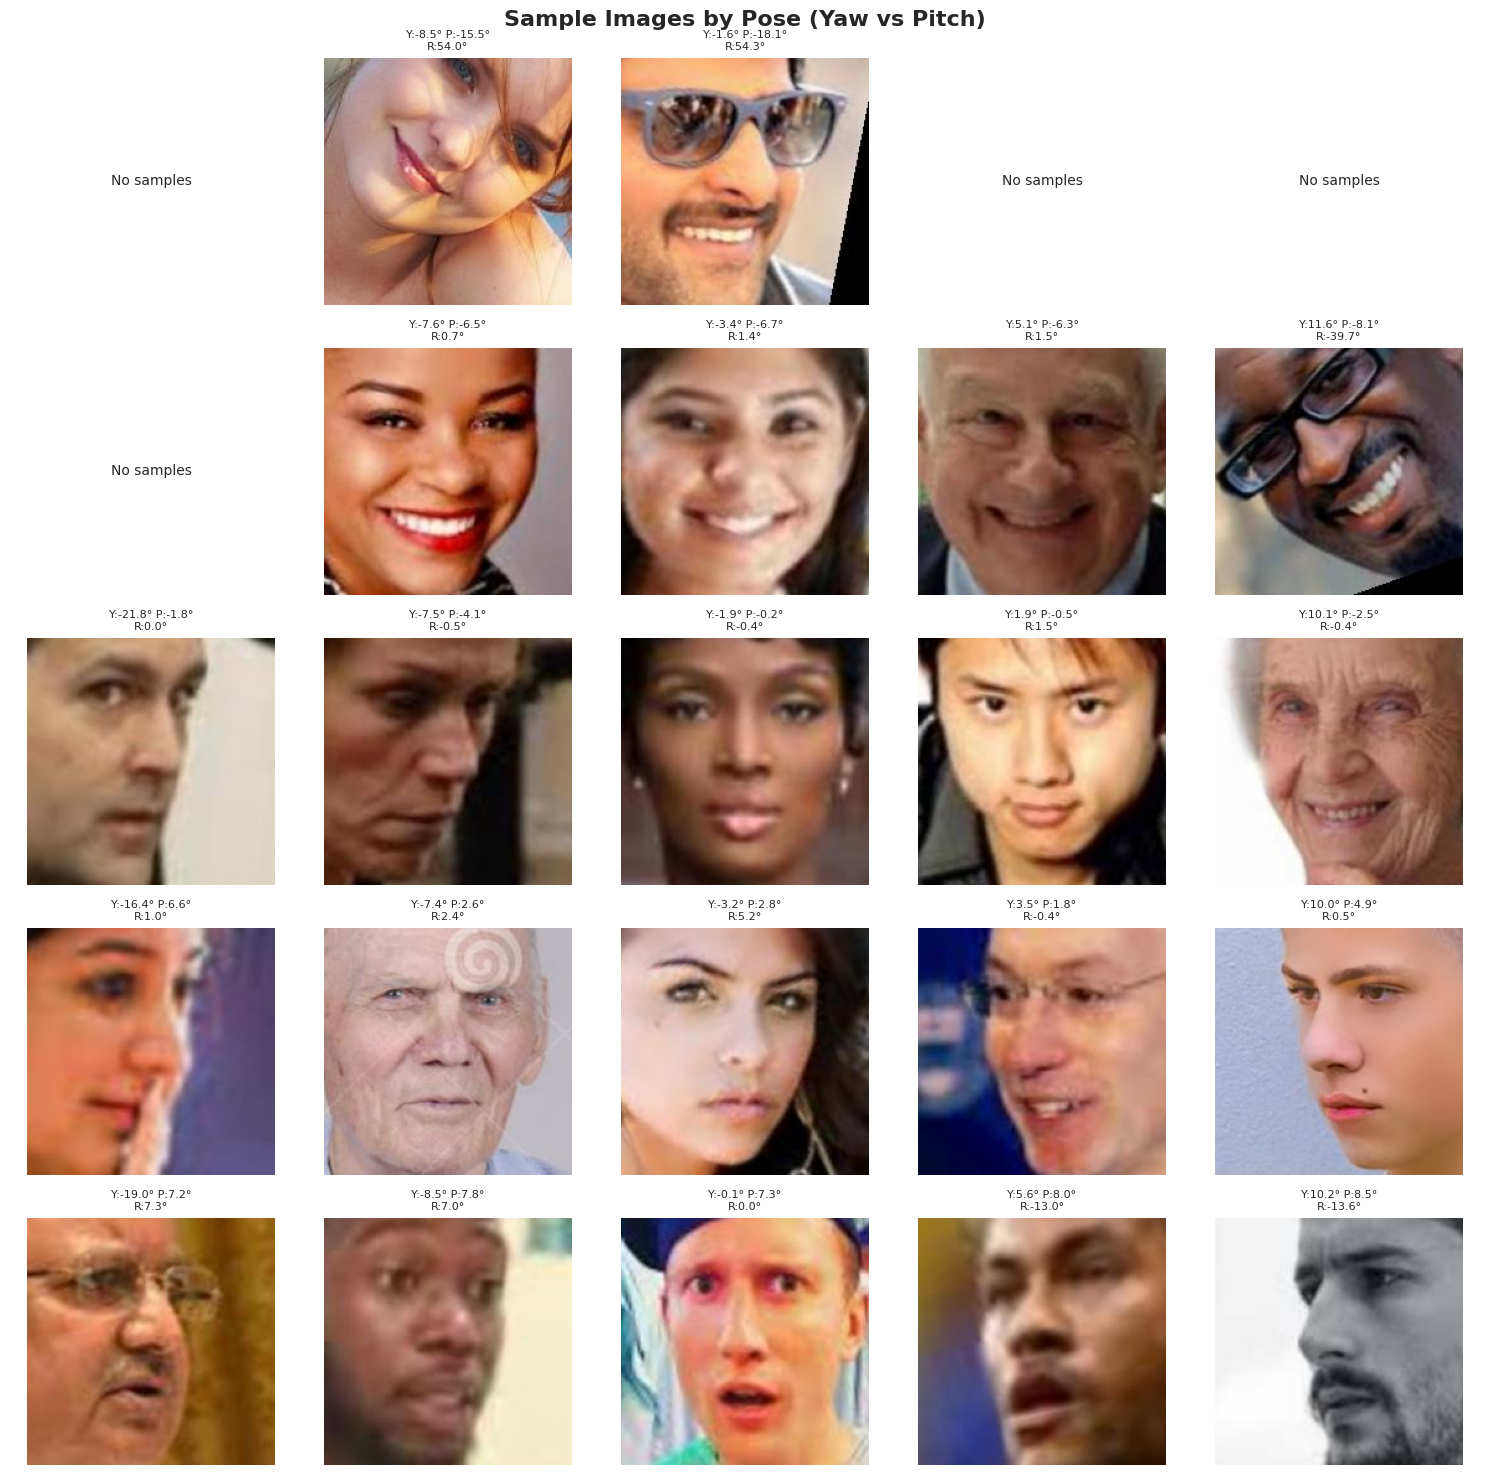

In [25]:
fig = plot_sample_grid(df,n_bins=5)
plt.savefig("ejemplo.png")

In [26]:
def generate_statistics_report(df):
    """Generate summary statistics"""
    print("=" * 60)
    print("HEAD POSE DATASET STATISTICS")
    print("=" * 60)
    print(f"\nTotal samples: {len(df)}")
    print(f"\n{'Angle':<10} {'Mean':<10} {'Std':<10} {'Min':<10} {'Max':<10}")
    print("-" * 60)
    
    for angle in ['yaw', 'pitch', 'roll']:
        stats = df[angle].describe()
        print(f"{angle.capitalize():<10} {stats['mean']:>9.2f}° {stats['std']:>9.2f}° {stats['min']:>9.2f}° {stats['max']:>9.2f}°")
    
    print(f"\n{'Face Area':<20} {df['surface_face_area'].mean():>12.1f} pixels²")
    print(f"{'Face Area Std':<20} {df['surface_face_area'].std():>12.1f} pixels²")
    
    # Pose coverage analysis with adjusted thresholds
    print("\n" + "=" * 60)
    print("POSE COVERAGE ANALYSIS (Adjusted Thresholds)")
    print("=" * 60)
    
    # Very frontal: tight thresholds
    very_frontal = len(df[(abs(df['yaw']) < 5) & (abs(df['pitch']) < 5) & (abs(df['roll']) < 5)])
    
    # Frontal: moderate thresholds
    frontal = len(df[(abs(df['yaw']) < 10) & (abs(df['pitch']) < 10)])
    
    # Slightly turned left/right
    slightly_turned = len(df[(abs(df['yaw']) >= 10) & (abs(df['yaw']) < 20)])
    
    # Significantly turned (what would be approaching profile)
    significantly_turned = len(df[abs(df['yaw']) >= 20])
    
    # Vertical inclination
    inclined_up = len(df[df['pitch'] > 8])
    inclined_down = len(df[df['pitch'] < -8])
    
    # Head tilt
    tilted = len(df[abs(df['roll']) > 10])
    significantly_tilted = len(df[abs(df['roll']) > 20])
    
    print(f"\nVery frontal (|yaw|<5°, |pitch|<5°, |roll|<5°): {very_frontal} ({100*very_frontal/len(df):.1f}%)")
    print(f"Frontal (|yaw|<10°, |pitch|<10°): {frontal} ({100*frontal/len(df):.1f}%)")
    print(f"Slightly turned (10°≤|yaw|<20°): {slightly_turned} ({100*slightly_turned/len(df):.1f}%)")
    print(f"Significantly turned (|yaw|≥20°): {significantly_turned} ({100*significantly_turned/len(df):.1f}%)")
    print(f"Inclined up (pitch>8°): {inclined_up} ({100*inclined_up/len(df):.1f}%)")
    print(f"Inclined down (pitch<-8°): {inclined_down} ({100*inclined_down/len(df):.1f}%)")
    print(f"Tilted heads (|roll|>10°): {tilted} ({100*tilted/len(df):.1f}%)")
    print(f"Significantly tilted (|roll|>20°): {significantly_tilted} ({100*significantly_tilted/len(df):.1f}%)")
    
    # Additional insights
    print("\n" + "-" * 60)
    print("POSE DIVERSITY INSIGHTS")
    print("-" * 60)
    
    # Calculate percentage within very tight bounds (±3 degrees)
    ultra_tight = len(df[(abs(df['yaw']) < 3) & (abs(df['pitch']) < 3) & (abs(df['roll']) < 3)])
    print(f"\nUltra-tight frontal (all angles <3°): {ultra_tight} ({100*ultra_tight/len(df):.1f}%)")
    
    # Multi-axis rotation (any two angles significant)
    multi_axis = len(df[((abs(df['yaw']) > 10) & (abs(df['pitch']) > 8)) | 
                         ((abs(df['yaw']) > 10) & (abs(df['roll']) > 10)) |
                         ((abs(df['pitch']) > 8) & (abs(df['roll']) > 10))])
    print(f"Multi-axis rotation (2+ angles significant): {multi_axis} ({100*multi_axis/len(df):.1f}%)")
    
    # Extreme poses (any angle beyond typical range)
    extreme_yaw = len(df[abs(df['yaw']) > 15])
    extreme_pitch = len(df[abs(df['pitch']) > 12])
    extreme_roll = len(df[abs(df['roll']) > 25])
    
    print(f"\nExtreme yaw (|yaw|>15°): {extreme_yaw} ({100*extreme_yaw/len(df):.1f}%)")
    print(f"Extreme pitch (|pitch|>12°): {extreme_pitch} ({100*extreme_pitch/len(df):.1f}%)")
    print(f"Extreme roll (|roll|>25°): {extreme_roll} ({100*extreme_roll/len(df):.1f}%)")
    
    print("=" * 60)

In [27]:
generate_statistics_report(df)

HEAD POSE DATASET STATISTICS

Total samples: 23477

Angle      Mean       Std        Min        Max       
------------------------------------------------------------
Yaw            -0.94°      2.46°    -23.53°     17.41°
Pitch          -0.77°      2.73°    -18.14°     13.47°
Roll            0.10°      2.48°    -39.66°     54.29°

Face Area                 27856.7 pixels²
Face Area Std              2482.1 pixels²

POSE COVERAGE ANALYSIS (Adjusted Thresholds)

Very frontal (|yaw|<5°, |pitch|<5°, |roll|<5°): 20020 (85.3%)
Frontal (|yaw|<10°, |pitch|<10°): 23392 (99.6%)
Slightly turned (10°≤|yaw|<20°): 73 (0.3%)
Significantly turned (|yaw|≥20°): 3 (0.0%)
Inclined up (pitch>8°): 36 (0.2%)
Inclined down (pitch<-8°): 35 (0.1%)
Tilted heads (|roll|>10°): 146 (0.6%)
Significantly tilted (|roll|>20°): 12 (0.1%)

------------------------------------------------------------
POSE DIVERSITY INSIGHTS
------------------------------------------------------------

Ultra-tight frontal (all angles <3°):